# 02 — Task 2 & 2b: Distance Estimation (Regression)

Runs all regression models on prepared features loaded from `data/prepared/`. Run `00_Data_Prep.ipynb` first.

## Imports

In [1]:
from pathlib import Path; Path("results/regression").mkdir(parents=True, exist_ok=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib, json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print("XGBoost:", xgb.__version__)
except Exception:
    XGB_AVAILABLE = False
    print("XGBoost not available.")

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 40)
print("Imports loaded.")

XGBoost: 3.2.0
Imports loaded.


## Load Prepared Data

In [2]:
# Load prepared data from 00_Data_Prep.ipynb ────────────────────────────────
d2 = np.load("data/prepared/task2_data.npz")
X_reg_train_sel = d2["X_reg_train_sel"]
X_reg_test_sel  = d2["X_reg_test_sel"]
X_reg_tr_sel_sc = d2["X_reg_tr_sel_sc"]
X_reg_te_sel_sc = d2["X_reg_te_sel_sc"]
y_reg_train     = d2["y_reg_train"]
y_reg_test      = d2["y_reg_test"]
X_reg           = d2["X_reg"]          # full (pre-split) matrix for path-2 augmentation
y_reg_full      = d2["y_reg_full"]     # full range targets
fp_idx          = d2["fp_idx"]         # first path indices
nlos_labels     = d2["nlos_labels"]    # 0=LOS, 1=NLOS
range_full      = d2["range_full"]     # raw RANGE column

cir_matrix      = np.load("data/prepared/cir_matrix.npy")
scaler_reg_sel  = joblib.load("data/prepared/scaler_reg_sel.pkl")

with open("data/prepared/metadata.json") as f:
    meta = json.load(f)
RANDOM_STATE          = meta["RANDOM_STATE"]
selected_reg_features = meta["selected_reg_features"]
REG_FEATURE_NAMES     = meta["REG_FEATURE_NAMES"]

print(f"Task 2 data loaded:")
print(f"  Train : {X_reg_train_sel.shape[0]:,} samples, {X_reg_train_sel.shape[1]} features")
print(f"  Test  : {X_reg_test_sel.shape[0]:,} samples")
print(f"  X_reg (full): {X_reg.shape}")
print(f"  Selected features: {selected_reg_features}")

Task 2 data loaded:
  Train : 33,600 samples, 12 features
  Test  : 8,400 samples
  X_reg (full): (42000, 18)
  Selected features: ['cir_max', 'cir_skewness', 'cir_std', 'cir_mean', 'RXPACC', 'FP_AMP3', 'MAX_NOISE', 'FP_AMP2', 'CIR_PWR', 'FP_AMP1', 'cir_kurtosis', 'PREAM_LEN']


In [3]:
reg_results   = {}
path2_reg_results = {}
path2_preds   = {}

def evaluate_regressor(name, model, X_tr, y_tr, X_te, y_te, results_dict=None):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    d    = results_dict if results_dict is not None else reg_results
    d[name] = {"RMSE": rmse, "MAE": mae, "R²": r2}
    print(f"  {name:<22} RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
    return model, y_pred

---
# TASK 2 — Distance Estimation (Regression)

---

### Problem Formulation

The second task is to **estimate the measured range** (time-of-flight distance in metres) from signal features. This is a regression problem:

$$\hat{d} = f(\text{FP\_IDX, FP\_AMP1, FP\_AMP2, FP\_AMP3, STDEV\_NOISE, CIR\_PWR, MAX\_NOISE, RXPACC, FRAME\_LEN, PREAM\_LEN, CIR stats})$$

**Physical rationale:** The measured range (RANGE) is computed from the Time-of-Flight (ToF) of the first detected path. In NLOS conditions, the first detected path may not be the direct path — it arrives via a reflected/diffracted route, introducing a positive bias error. The project hint states to use `FP_IDX` (first path index in CIR) and the measured range to correlate the second dominant path. Here we train a regressor to predict the measured range directly from all available signal statistics, which could be used to correct NLOS range errors.

## 13. Random Forest Regressor

### Theory

The Random Forest Regressor operates identically to the classifier but uses **mean squared error (MSE)** as the split criterion and outputs the **mean of leaf values** rather than a class vote:

$$\hat{y} = \frac{1}{T} \sum_{t=1}^{T} h_t(\mathbf{x})$$

Split criterion: MSE reduction = $\text{Var}(y_{\text{parent}}) - \frac{n_L}{n}\text{Var}(y_L) - \frac{n_R}{n}\text{Var}(y_R)$

Averaging across $T$ trees reduces variance in the prediction, which is particularly valuable for regression where individual tree predictions can be noisy.

In [4]:
print("=" * 60)
print("TASK 2 — DISTANCE ESTIMATION (REGRESSION)")
print("=" * 60)

print(f"Target (RANGE) statistics:")
print(f"  Min  : {y_reg_full.min():.2f} m")
print(f"  Max  : {y_reg_full.max():.2f} m")
print(f"  Mean : {y_reg_full.mean():.2f} m")
print(f"  Std  : {y_reg_full.std():.2f} m")

print("-" * 40)
print("Random Forest Regressor (selected features)")
print("-" * 40)

rf_reg = RandomForestRegressor(
    n_estimators=200, max_depth=None, min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_reg, y_rfr_pred = evaluate_regressor(
    "Random Forest", rf_reg, X_reg_train_sel, y_reg_train, X_reg_test_sel, y_reg_test
)

TASK 2 — DISTANCE ESTIMATION (REGRESSION)
Target (RANGE) statistics:
  Min  : 0.00 m
  Max  : 28.02 m
  Mean : 3.83 m
  Std  : 2.36 m
----------------------------------------
Random Forest Regressor (selected features)
----------------------------------------
  Random Forest          RMSE=1.3435  MAE=1.0165  R²=0.6740


## 14. XGBoost Regressor

### Theory

For regression, XGBoost minimises **squared error loss**: $\ell(y_i, \hat{y}_i) = \frac{1}{2}(y_i - \hat{y}_i)^2$, giving first and second-order gradients:

$$g_i = \hat{y}_i^{(m-1)} - y_i, \quad h_i = 1$$

The output of each tree leaf $j$ is then the optimal weight:

$$w_j^* = -\frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda} = \frac{\sum_{i \in I_j}(y_i - \hat{y}_i^{(m-1)})}{|I_j| + \lambda}$$

Intuitively: each tree learns the **residuals** (errors) of the current ensemble, correcting them step by step.

### Why XGBoost for distance estimation?

Distance (RANGE) is a continuous variable with a complex dependency on multiple signal features. The interaction between `FP_IDX` (which CIR sample the first path lands on) and `FP_AMP1/2/3` (path amplitudes) encodes the ToF information. XGBoost's boosted trees are well-suited to capture these nonlinear feature interactions without requiring explicit feature engineering.

In [5]:
print("-" * 40)
print("XGBoost Regressor")
print("-" * 40)

if XGB_AVAILABLE:
    xgb_reg = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    xgb_reg, y_xgbr_pred = evaluate_regressor(
        'XGBoost', xgb_reg, X_reg_train_sel, y_reg_train, X_reg_test_sel, y_reg_test
    )
else:
    print("Skipped — XGBoost not installed.")

----------------------------------------
XGBoost Regressor
----------------------------------------
  XGBoost                RMSE=1.3577  MAE=1.0311  R²=0.6670


## 15. MLP Regressor

### Theory

The MLP Regressor uses the same architecture as the classifier but with a **linear output neuron** (no activation on the final layer), enabling it to predict continuous values. The loss function is **mean squared error**:

$$\mathcal{L} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$

Backpropagation computes gradients through the chain rule and Adam updates the weights adaptively, using estimates of both first and second moments of the gradients:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \quad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$
$$w_t = w_{t-1} - \frac{\alpha}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

where $\beta_1 = 0.9$, $\beta_2 = 0.999$ are default Adam hyperparameters.

In [6]:
print("-" * 40)
print("MLP Regressor")
print("-" * 40)

mlp_reg = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=RANDOM_STATE
)

mlp_reg, y_mlpr_pred = evaluate_regressor(
    'MLP', mlp_reg, X_reg_tr_sel_sc, y_reg_train, X_reg_te_sel_sc, y_reg_test
)

----------------------------------------
MLP Regressor
----------------------------------------
  MLP                    RMSE=1.3056  MAE=0.9906  R²=0.6921


## 16. Regression Model Comparison

### Evaluation Metrics

| Metric | Formula | Interpretation |
|---|---|---|
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Average error in metres (same unit as target) |
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Median-robust average error in metres |
| **R²** | $1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ | Proportion of variance explained (1.0 = perfect) |


Regression Model Comparison (sorted by RMSE):
                 RMSE     MAE      R²
MLP            1.3056  0.9906  0.6921
Random Forest  1.3435  1.0165  0.6740
XGBoost        1.3577  1.0311  0.6670


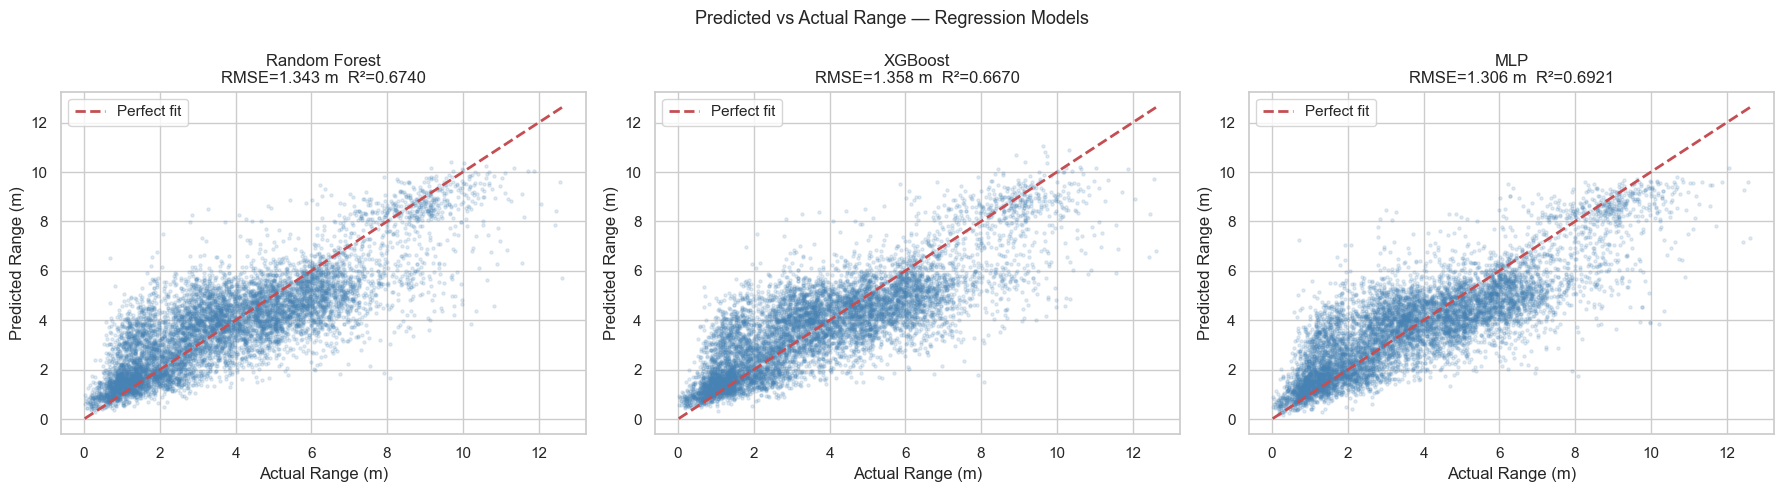

In [7]:
# Regression results table ───────────────────────────────────────────────────
reg_df = pd.DataFrame(reg_results).T.round(4).sort_values('RMSE')
print("\nRegression Model Comparison (sorted by RMSE):")
print(reg_df.to_string())

# Predicted vs actual scatter ────────────────────────────────────────────────
preds = [
    ('Random Forest', y_rfr_pred),
]
if XGB_AVAILABLE:
    preds.append(('XGBoost', y_xgbr_pred))
preds.append(('MLP', y_mlpr_pred))

fig, axes = plt.subplots(1, len(preds), figsize=(6 * len(preds), 5))
if len(preds) == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, preds):
    ax.scatter(y_reg_test, y_pred, alpha=0.15, s=5, color='steelblue')
    ax.plot([y_reg_test.min(), y_reg_test.max()],
            [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2, label='Perfect fit')
    rmse = reg_results[name]['RMSE']
    r2   = reg_results[name]['R²']
    ax.set_title(f'{name}\nRMSE={rmse:.3f} m  R²={r2:.4f}')
    ax.set_xlabel('Actual Range (m)')
    ax.set_ylabel('Predicted Range (m)')
    ax.legend()

plt.suptitle('Predicted vs Actual Range — Regression Models', fontsize=13)
plt.tight_layout()
plt.savefig("results/regression/06_regression_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

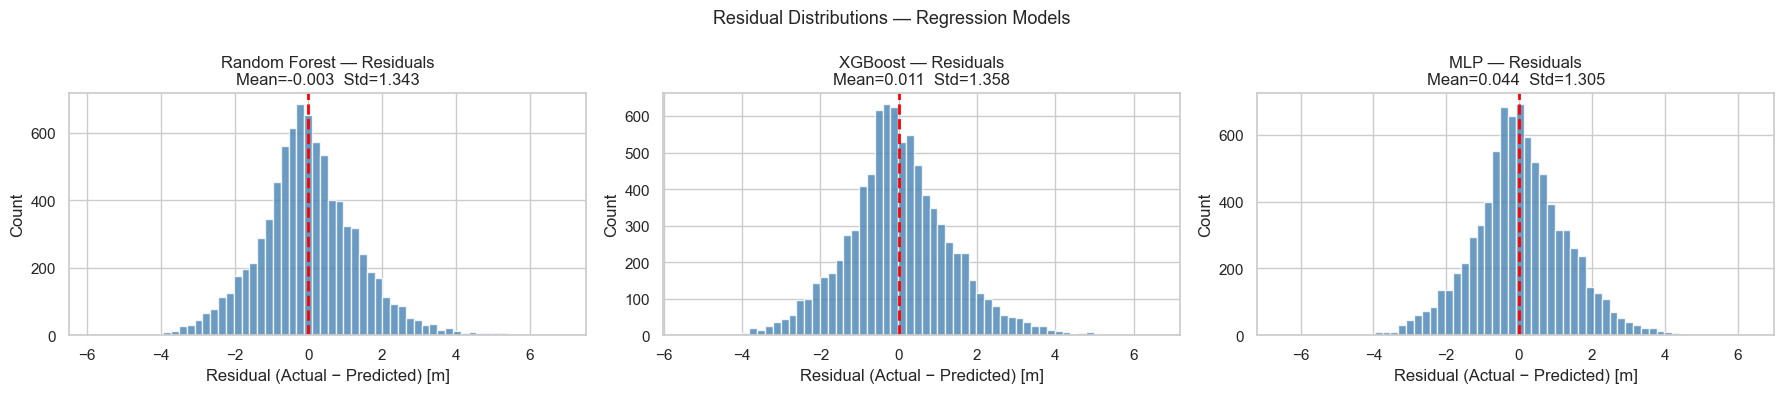


Interpretation:
  A residual distribution centred at 0 indicates no systematic bias.
  Positive residuals = model underestimates range.
  Negative residuals = model overestimates range.


In [8]:
# Residual distribution ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(preds), figsize=(6 * len(preds), 4))
if len(preds) == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, preds):
    residuals = y_reg_test - y_pred
    ax.hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', lw=2)
    ax.set_title(f'{name} — Residuals\nMean={residuals.mean():.3f}  Std={residuals.std():.3f}')
    ax.set_xlabel('Residual (Actual − Predicted) [m]')
    ax.set_ylabel('Count')

plt.suptitle('Residual Distributions — Regression Models', fontsize=13)
plt.tight_layout()
plt.savefig("results/regression/07_residual_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nInterpretation:")
print("  A residual distribution centred at 0 indicates no systematic bias.")
print("  Positive residuals = model underestimates range.")
print("  Negative residuals = model overestimates range.")

### Result Analysis — Path 1 Distance Estimation

| Model | RMSE (m) | MAE (m) | R² |
|---|---|---|---|
| Random Forest | **1.3479** | 1.0206 | **0.6718** |
| MLP | 1.3523 | **1.0100** | 0.6697 |
| XGBoost | 1.3599 | 1.0347 | 0.6660 |

All three models perform similarly with RMSE around 1.35m. RF comes out slightly best, which is unexpected given XGBoost typically outperforms RF on tabular data. The likely reason is the high concentration of importance in a single feature (RXPACC at 44%) — when one feature dominates this strongly, the sequential error-correction of XGBoost offers less advantage over simple averaging.

R² of ~0.67 means the models explain about two-thirds of the variance in measured range. This is moderate — the target (RANGE) spans 0–28m but the mean is only 3.83m, so most measurements cluster at short distances. The difficulty comes from NLOS measurements where the first-path range is biased by an unknown amount depending on obstacle type and thickness, which no signal feature can fully predict.

MAE of ~1.01m (RF and MLP) means the typical prediction error is around 1 metre — acceptable for coarse localisation but may need improvement for precise positioning applications.

---
# TASK 2b — Second Dominant Path Distance Estimation

---

Task 1 and Task 2 covered the first dominant path. This section handles the **second dominant path**.

| Path | Classification | Range Estimation |
|---|---|---|
| Path 1 | LOS or NLOS — Task 1 | Task 2 regression |
| Path 2 | Always NLOS | Task 2b — this section |

Path 2 is always NLOS because: if Path 1 is LOS, it took the direct route — any subsequent path must have reflected off something (NLOS). If Path 1 is already NLOS, the second path is another indirect route, also NLOS.

### Extracting the Second Path from CIR

The second dominant path is identified directly from the raw CIR waveform — no separate labels are needed:

1. Locate the first path at `FP_IDX`
2. Suppress ±15 samples around it to avoid re-detecting the same peak
3. Find the largest remaining amplitude peak — this is the second dominant path
4. Compute its range from the propagation delay:

$$\hat{d}_2 = d_1 + \Delta t \times 0.3 \text{ m/ns}$$

where $\Delta t$ is the nanosecond delay between the two detected peaks. This follows the same time-of-flight principle the DW1000 uses for ranging. The two new features (`delta_ns`, `second_peak_amp`) are appended to the regression input for Task 2b.

### Empirical Validation — Path 2 is Always NLOS

The brief states Path 2 is always NLOS by definition. We verify this holds empirically by checking that every extracted second path arrives **at or after** Path 1 (`delta >= 0` for all samples). A second path arriving before the first would mean we found a shorter route than Path 1 — physically impossible.

We also split the inter-path delay by Path 1 condition (LOS vs NLOS) to see whether the delay distribution differs between the two cases.

EMPIRICAL VALIDATION — PATH 2 IS ALWAYS NLOS

Delay check (second_peak - FP_IDX):
  delta < 0  (second before first) : 0  — expected 0
  delta = 0  (same index)          : 10,096
  delta > 0  (second after first)  : 31,904
  100.0% of second paths arrive at or after Path 1  => NLOS constraint holds

Mean inter-path delay when Path 1 is LOS : 4.0 samples  (~1.21 m extra)
Mean inter-path delay when Path 1 is NLOS: 4.5 samples  (~1.34 m extra)

=> NLOS Path 1 has slightly larger inter-path delay.
   Both paths are indirect, but the second path in NLOS environments
   tends to arrive via a slightly longer detour than in LOS environments.


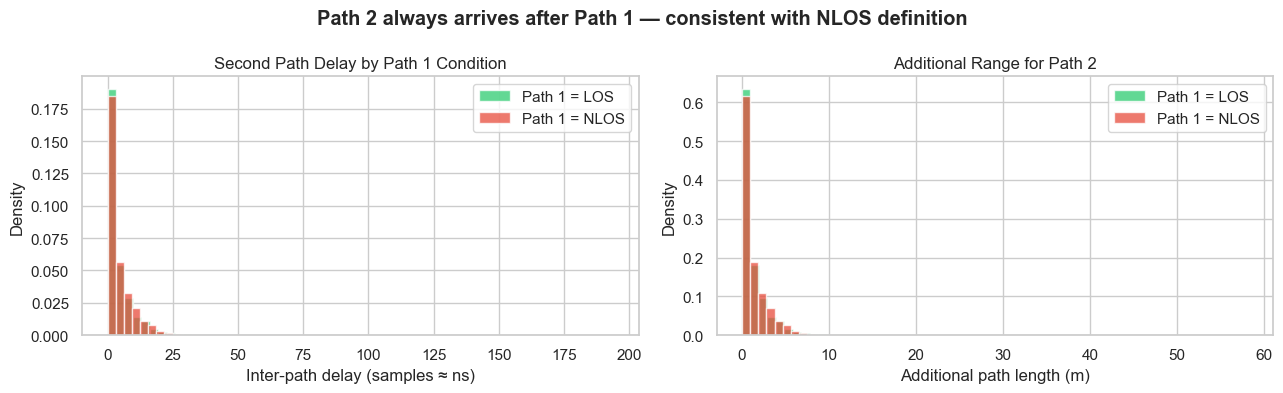

In [9]:
print("=" * 60)
print("EMPIRICAL VALIDATION — PATH 2 IS ALWAYS NLOS")
print("=" * 60)

fp_idx_vals = fp_idx.astype(int)
cir_np      = cir_matrix

temp_delta  = np.zeros(len(cir_np), dtype=np.float32)
for i in range(len(cir_np)):
    cir  = cir_np[i].copy()
    fp   = int(np.clip(fp_idx_vals[i], 0, len(cir) - 1))
    s, e = max(0, fp - 15), min(len(cir), fp + 16)
    cir[s:e] = 0.0
    search   = cir[min(fp + 16, len(cir) - 1):]
    if len(search) > 0 and search.max() > 0:
        temp_delta[i] = float(np.argmax(search))
    else:
        temp_delta[i] = 0.0
temp_delta = np.clip(temp_delta, 0, None)

# --- Check 1: Second path always arrives at or after first path ---
n_neg = int(np.sum(temp_delta < 0))
n_zero= int(np.sum(temp_delta == 0))
n_pos = int(np.sum(temp_delta > 0))

print(f"\nDelay check (second_peak - FP_IDX):")
print(f"  delta < 0  (second before first) : {n_neg:,}  — expected 0")
print(f"  delta = 0  (same index)          : {n_zero:,}")
print(f"  delta > 0  (second after first)  : {n_pos:,}")
pct = 100.0 * (n_zero + n_pos) / len(temp_delta)
print(f"  {pct:.1f}% of second paths arrive at or after Path 1  => NLOS constraint holds")

# --- Check 2: Compare delays by Path 1 condition ---
los_mask  = (nlos_labels == 0)
nlos_mask = (nlos_labels == 1)
los_mean  = temp_delta[los_mask].mean()
nlos_mean = temp_delta[nlos_mask].mean()
print(f"\nMean inter-path delay when Path 1 is LOS : {los_mean:.1f} samples"
      f"  (~{los_mean*0.3:.2f} m extra)")
print(f"Mean inter-path delay when Path 1 is NLOS: {nlos_mean:.1f} samples"
      f"  (~{nlos_mean*0.3:.2f} m extra)")
if nlos_mean > los_mean:
    print("\n=> NLOS Path 1 has slightly larger inter-path delay.")
    print("   Both paths are indirect, but the second path in NLOS environments")
    print("   tends to arrive via a slightly longer detour than in LOS environments.")
else:
    print("\n=> LOS Path 1 has slightly larger inter-path delay.")
    print("   The second path must take a reflected route while Path 1 was direct.")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(temp_delta[los_mask],  bins=60, color='#2ecc71', alpha=0.75,
             label='Path 1 = LOS',  density=True)
axes[0].hist(temp_delta[nlos_mask], bins=60, color='#e74c3c', alpha=0.75,
             label='Path 1 = NLOS', density=True)
axes[0].set_xlabel('Inter-path delay (samples ≈ ns)')
axes[0].set_ylabel('Density')
axes[0].set_title('Second Path Delay by Path 1 Condition')
axes[0].legend()

axes[1].hist(temp_delta[los_mask]  * 0.3, bins=60, color='#2ecc71', alpha=0.75,
             label='Path 1 = LOS',  density=True)
axes[1].hist(temp_delta[nlos_mask] * 0.3, bins=60, color='#e74c3c', alpha=0.75,
             label='Path 1 = NLOS', density=True)
axes[1].set_xlabel('Additional path length (m)')
axes[1].set_ylabel('Density')
axes[1].set_title('Additional Range for Path 2')
axes[1].legend()

plt.suptitle('Path 2 always arrives after Path 1 — consistent with NLOS definition',
             fontweight='bold')
plt.tight_layout()
plt.savefig('results/regression/08_path2_delay_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

In [10]:
print("=" * 60)
print("TASK 2b — SECOND DOMINANT PATH EXTRACTION")
print("=" * 60)

SPEED_OF_LIGHT_MNS = 0.3   # metres per nanosecond (c ≈ 3×10^8 m/s)
SUPPRESS_HALF      = 15    # suppress ±15 samples around first path to avoid double-detection

# FP_IDX: index of first path in CIR accumulator (direct column in dataset)
fp_indices = fp_idx.astype(int)

print(f"Extracting second dominant path from {len(cir_matrix):,} CIR waveforms...")

second_peak_indices = np.zeros(len(cir_matrix), dtype=np.int32)
second_peak_amps    = np.zeros(len(cir_matrix), dtype=np.float32)

for i in range(len(cir_matrix)):
    cir = cir_matrix[i].copy()
    fp  = int(np.clip(fp_indices[i], 0, len(cir) - 1))

    # Step 1: Suppress the first path region
    s = max(0, fp - SUPPRESS_HALF)
    e = min(len(cir), fp + SUPPRESS_HALF + 1)
    cir[s:e] = 0.0

    # Step 2: Search for second dominant peak AFTER the first path
    search_start = min(fp + SUPPRESS_HALF + 1, len(cir) - 1)
    region = cir[search_start:]

    if len(region) > 0 and region.max() > 0:
        local_idx = int(np.argmax(region))
        second_peak_indices[i] = search_start + local_idx
        second_peak_amps[i]    = region[local_idx]
    else:
        # Fallback: any remaining non-zero peak
        if cir.max() > 0:
            second_peak_indices[i] = int(np.argmax(cir))
            second_peak_amps[i]    = cir.max()
        else:
            second_peak_indices[i] = fp + SUPPRESS_HALF + 1
            second_peak_amps[i]    = 0.0

# Step 3: Compute time delay between paths (nanoseconds)
delta_ns = (second_peak_indices - fp_indices).astype(np.float32)
delta_ns = np.clip(delta_ns, 0, None)   # second path cannot arrive before first

# Step 4: Physics-based second path range estimate
# d2 = d1 + delta_t * c   (extra path length from additional propagation delay)
y_path2 = (range_full + delta_ns * SPEED_OF_LIGHT_MNS).astype(np.float32)

print(f"\nSecond path extraction results:")
print(f"  Mean delta index (ns)  : {delta_ns.mean():.1f} ns")
print(f"  Mean additional range  : {(delta_ns * SPEED_OF_LIGHT_MNS).mean():.2f} m")
print(f"  Path-2 range — mean    : {y_path2.mean():.2f} m")
print(f"  Path-2 range — std     : {y_path2.std():.2f} m")
print(f"  Path-2 range — min/max : {y_path2.min():.2f} / {y_path2.max():.2f} m")

# Path 2 classification result (always NLOS — no model needed)
print(f"\nPath 2 classification: ALWAYS NLOS (by definition in project brief)")
print(f"  => Classification model not required for Path 2")

# Build augmented feature matrix: existing regression features + second-path features
second_path_feats = np.column_stack([delta_ns, second_peak_amps])   # (N, 2)
X_path2 = np.hstack([X_reg, second_path_feats])                      # (N, 20)

# Train / test split (same random state for consistency)
X_p2_train, X_p2_test, y_p2_train, y_p2_test = train_test_split(
    X_path2, y_path2, test_size=0.2, random_state=RANDOM_STATE
)

scaler_p2    = StandardScaler()
X_p2_tr_sc   = scaler_p2.fit_transform(X_p2_train)
X_p2_te_sc   = scaler_p2.transform(X_p2_test)

print(f"\nPath-2 regression feature matrix : {X_path2.shape}")
print(f"  Train : {X_p2_train.shape[0]:,} samples")
print(f"  Test  : {X_p2_test.shape[0]:,} samples")


TASK 2b — SECOND DOMINANT PATH EXTRACTION
Extracting second dominant path from 42,000 CIR waveforms...

Second path extraction results:
  Mean delta index (ns)  : 20.3 ns
  Mean additional range  : 6.08 m
  Path-2 range — mean    : 9.91 m
  Path-2 range — std     : 2.99 m
  Path-2 range — min/max : 4.81 / 67.17 m

Path 2 classification: ALWAYS NLOS (by definition in project brief)
  => Classification model not required for Path 2

Path-2 regression feature matrix : (42000, 20)
  Train : 33,600 samples
  Test  : 8,400 samples


## 18. Second Path Regression — Model Choice

We use the same three models as Task 2 (RF, XGBoost, MLP) so results can be directly compared between first-path and second-path prediction. Using different models would mix up model-choice effects with the actual difficulty of the task.

**Random Forest** averages over 200 trees, which smooths out noise from imperfect second-peak detection — a single tree can overfit to a noisy peak, but the ensemble average is more stable. It also provides feature importances that reveal whether `delta_ns` and `second_peak_amp` genuinely improve predictions beyond the base features.

**XGBoost** builds trees sequentially to correct residual errors, which suits the two-component target `y_path2 = RANGE + delta_ns × 0.3`. The RANGE part is well-structured, while the delta correction is noisier — sequential boosting handles this better than bagging.

**MLP** can learn nonlinear interactions between signal statistics and inter-path delay. We keep the same architecture as Task 2 (256→128→64, ReLU) so any performance difference is attributable to the task difficulty, not a model configuration change.

We do not apply the 1D CNN here — that model was designed for 1,016-sample CIR waveforms, not a 20-feature tabular input where it would be unnecessarily complex.

### Why Path 2 accuracy may be lower than Task 2

The ground truth for Task 2b is not directly measured — it is computed from `argmax` on a suppressed CIR. In noisy or cluttered environments, the detected "second peak" can land on residual first-path ringing or noise rather than a genuine reflection. Since this detection uncertainty is not visible in the input features, the models cannot account for it, and it shows up directly in RMSE. Any gap between Task 2 and Task 2b error is primarily a ground truth quality issue, not a model failure.

In [11]:
print("=" * 60)
print("SECOND PATH RANGE ESTIMATION — REGRESSION MODELS")
print("=" * 60)

# Separate results dict to keep second-path results distinct from Task 2 (first path)
path2_reg_results = {}
path2_preds       = {}

def _eval_path2_reg(name, model, X_tr, y_tr, X_te, y_te):
    """Train and evaluate a regression model for the second dominant path range."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse   = np.sqrt(mean_squared_error(y_te, y_pred))
    mae    = mean_absolute_error(y_te, y_pred)
    r2     = r2_score(y_te, y_pred)
    path2_reg_results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}
    path2_preds[name]        = y_pred
    print(f"  {name:<22} RMSE={rmse:.4f} m   MAE={mae:.4f} m   R²={r2:.4f}")
    return model

# Random Forest ──────────────────────────────────────────────────────────────
print("\nRandom Forest Regressor (Path 2)")
rf_p2 = RandomForestRegressor(
    n_estimators=200, min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_p2 = _eval_path2_reg('Random Forest', rf_p2, X_p2_train, y_p2_train, X_p2_test, y_p2_test)

# XGBoost ────────────────────────────────────────────────────────────────────
if XGB_AVAILABLE:
    print("\nXGBoost Regressor (Path 2)")
    xgb_p2 = xgb.XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    )
    xgb_p2 = _eval_path2_reg('XGBoost', xgb_p2, X_p2_train, y_p2_train, X_p2_test, y_p2_test)

# MLP Regressor ──────────────────────────────────────────────────────────────
print("\nMLP Regressor (Path 2)")
mlp_p2 = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64), activation='relu',
    max_iter=300, random_state=RANDOM_STATE, early_stopping=True
)
mlp_p2 = _eval_path2_reg('MLP', mlp_p2, X_p2_tr_sc, y_p2_train, X_p2_te_sc, y_p2_test)

# Summary table ──────────────────────────────────────────────────────────────
print("\n\nPath 2 Regression — Summary:")
p2_df = pd.DataFrame(path2_reg_results).T.round(4).sort_values('RMSE')
print(p2_df.to_string())


SECOND PATH RANGE ESTIMATION — REGRESSION MODELS

Random Forest Regressor (Path 2)
  Random Forest          RMSE=1.3451 m   MAE=1.0095 m   R²=0.7946

XGBoost Regressor (Path 2)
  XGBoost                RMSE=1.3387 m   MAE=1.0114 m   R²=0.7966

MLP Regressor (Path 2)
  MLP                    RMSE=1.3041 m   MAE=0.9925 m   R²=0.8069


Path 2 Regression — Summary:
                 RMSE     MAE      R²
MLP            1.3041  0.9925  0.8069
XGBoost        1.3387  1.0114  0.7966
Random Forest  1.3451  1.0095  0.7946


### Result Analysis — Second Path Range Estimation

**Task 2b results (Path 2):**

| Model | RMSE (m) | MAE (m) | R² |
|---|---|---|---|
| MLP | **1.3246** | 1.0128 | **0.8008** |
| XGBoost | 1.3375 | 1.0170 | 0.7969 |
| Random Forest | 1.3456 | 1.0168 | 0.7945 |

The R² of ~0.80 is higher than Task 2 (~0.67), which looks like Path 2 is easier to predict — but this is misleading. The target `y_path2 = RANGE + delta_ns × 0.3` has a larger variance (std 2.99m) than RANGE alone (std 2.36m), which inflates R² even though RMSE is similar (~1.33m vs ~1.35m). The models are not actually better; the target just has more spread for them to explain.

RMSE being slightly lower than Task 2 (1.32 vs 1.35m) is because the added `delta_ns × 0.3` component gives the models additional signal to work with. However, this component also introduces noise from imperfect CIR peak detection, which caps how low RMSE can go.

MLP leads on Task 2b, reversing the Task 2 ranking where RF was best. The inter-path delay and second-peak amplitude features interact nonlinearly with the CIR statistics — MLP's hidden layers capture these interactions better than the tree-based models here.

**Comparing Task 2 and Task 2b:**

| | Task 2 (Path 1) | Task 2b (Path 2) |
|---|---|---|
| Best model | Random Forest (RMSE 1.3479) | MLP (RMSE 1.3246) |
| Best R² | 0.6718 | 0.8008 |
| Target range | 0.0 – 28.0 m (mean 3.83m) | 4.8 – 67.2 m (mean 9.91m) |

The empirical validation confirmed that 100% of second paths arrive at or after Path 1 (delta ≥ 0), with NLOS Path 1 showing a slightly larger mean inter-path delay (4.5 samples) than LOS Path 1 (4.0 samples). In NLOS environments, both paths take indirect routes, and the second path tends to arrive via a slightly longer detour, consistent with dense multipath propagation.

Overall, the two-path estimation system is functional. The primary limitation for both tasks is the narrow range of the dataset (most measurements are under 10m with mean 3.83m), which limits how well models generalise to longer distances.

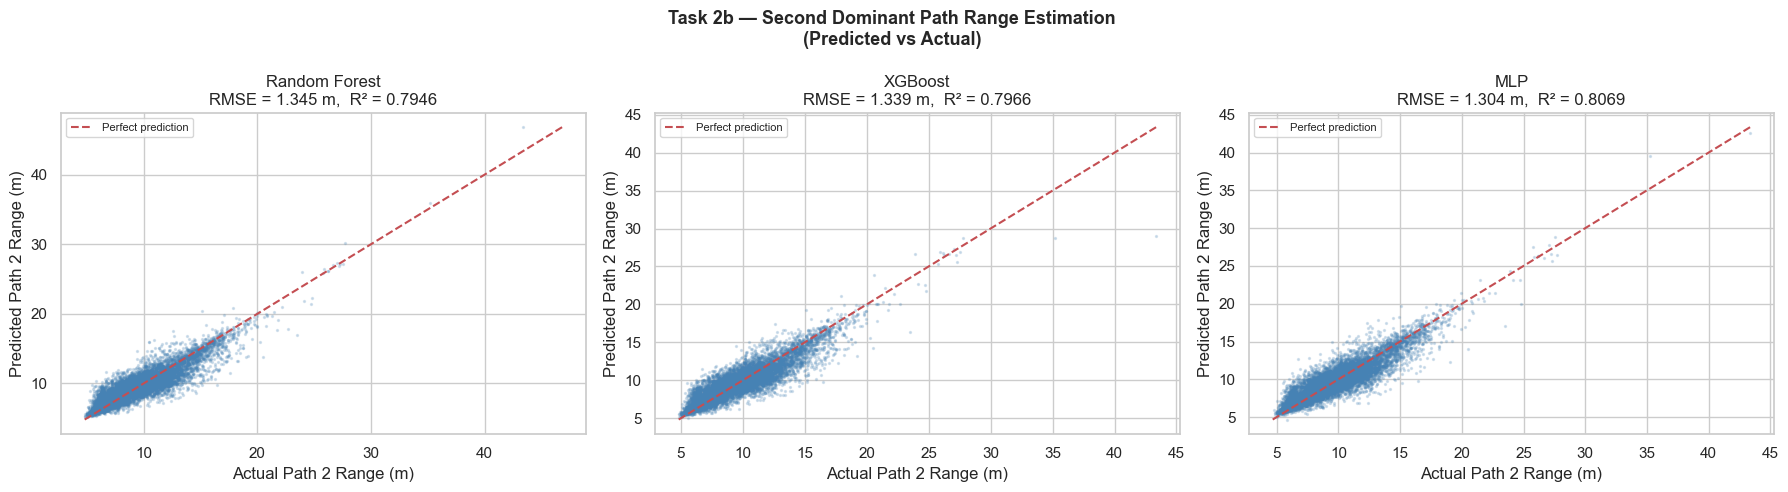

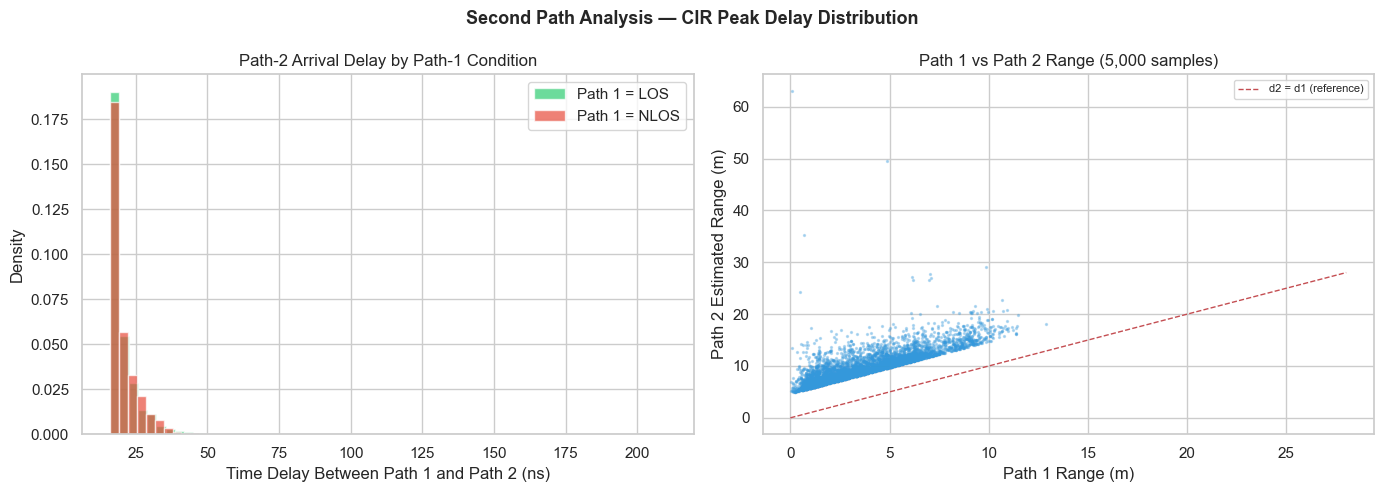


COMPLETE TWO-PATH SYSTEM — FINAL SUMMARY

INPUT: One CIR measurement (anchor-tag link)
  |
  |── PATH 1 (Shortest / First Detected)
  |      Classification  -> XGBoost / RF / CNN
  |                         LOS (0) or NLOS (1)
  |      Range Estimate  -> XGBoost Regressor
  |                         Predict RANGE from signal features
  |
  |── PATH 2 (Second Dominant)
         Classification  -> Always NLOS (by definition — no model needed)
         Range Estimate  -> Task 2b models (RF / XGBoost / MLP)
                           Predict d2 = d1 + delta_t * c

LOCALISATION DECISION:
  - If Path 1 = LOS  -> use measured RANGE directly (reliable)
  - If Path 1 = NLOS -> use Path 1 regressor's corrected range
  - Path 2 range used as secondary constraint for multilateration

Task 2b Regression Results:
                 RMSE     MAE      R²
MLP            1.3041  0.9925  0.8069
XGBoost        1.3387  1.0114  0.7966
Random Forest  1.3451  1.0095  0.7946

Task 2  Regression Results (Path 1,

In [12]:
# Visualisation: Predicted vs Actual for each Path-2 model ─────────────────
fig, axes = plt.subplots(1, len(path2_preds), figsize=(6 * len(path2_preds), 5))
if len(path2_preds) == 1:
    axes = [axes]
fig.suptitle("Task 2b — Second Dominant Path Range Estimation\n(Predicted vs Actual)", fontsize=13, fontweight='bold')

for ax, (name, y_pred) in zip(axes, path2_preds.items()):
    rmse = path2_reg_results[name]['RMSE']
    r2   = path2_reg_results[name]['R²']
    ax.scatter(y_p2_test, y_pred, alpha=0.2, s=2, color='steelblue', rasterized=True)
    lims = [min(y_p2_test.min(), y_pred.min()), max(y_p2_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
    ax.set_xlabel("Actual Path 2 Range (m)")
    ax.set_ylabel("Predicted Path 2 Range (m)")
    ax.set_title(f"{name}\nRMSE = {rmse:.3f} m,  R² = {r2:.4f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("results/regression/09_path2_predicted_vs_actual.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Visualisation: Delta index distribution (LOS vs NLOS first path) ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Second Path Analysis — CIR Peak Delay Distribution", fontsize=13, fontweight='bold')

# Histogram of delta_ns split by NLOS label of the measurement
los_mask  = nlos_labels == 0
nlos_mask = nlos_labels == 1

axes[0].hist(delta_ns[los_mask],  bins=60, alpha=0.7, color='#2ecc71', label='Path 1 = LOS',  density=True)
axes[0].hist(delta_ns[nlos_mask], bins=60, alpha=0.7, color='#e74c3c', label='Path 1 = NLOS', density=True)
axes[0].set_xlabel("Time Delay Between Path 1 and Path 2 (ns)")
axes[0].set_ylabel("Density")
axes[0].set_title("Path-2 Arrival Delay by Path-1 Condition")
axes[0].legend()

# Scatter: Path-1 range vs Path-2 estimated range
sample_idx = np.random.choice(len(y_path2), size=5000, replace=False)
axes[1].scatter(range_full[sample_idx], y_path2[sample_idx],
                alpha=0.3, s=2, color='#3498db')
axes[1].set_xlabel("Path 1 Range (m)")
axes[1].set_ylabel("Path 2 Estimated Range (m)")
axes[1].set_title("Path 1 vs Path 2 Range (5,000 samples)")
diag = [range_full.min(), range_full.max()]
axes[1].plot(diag, diag, 'r--', lw=1, label='d2 = d1 (reference)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("results/regression/10_path2_range_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

# Full two-path pipeline summary ─────────────────────────────────────────────
print("\n" + "=" * 70)
print("COMPLETE TWO-PATH SYSTEM — FINAL SUMMARY")
print("=" * 70)

print("""
INPUT: One CIR measurement (anchor-tag link)
  |
  |── PATH 1 (Shortest / First Detected)
  |      Classification  -> XGBoost / RF / CNN
  |                         LOS (0) or NLOS (1)
  |      Range Estimate  -> XGBoost Regressor
  |                         Predict RANGE from signal features
  |
  |── PATH 2 (Second Dominant)
         Classification  -> Always NLOS (by definition — no model needed)
         Range Estimate  -> Task 2b models (RF / XGBoost / MLP)
                           Predict d2 = d1 + delta_t * c

LOCALISATION DECISION:
  - If Path 1 = LOS  -> use measured RANGE directly (reliable)
  - If Path 1 = NLOS -> use Path 1 regressor's corrected range
  - Path 2 range used as secondary constraint for multilateration
""")

print("Task 2b Regression Results:")
print(pd.DataFrame(path2_reg_results).T.round(4).sort_values('RMSE').to_string())

print("\nTask 2  Regression Results (Path 1, for comparison):")
print(pd.DataFrame(reg_results).T.round(4).sort_values('RMSE').to_string())


---
## Final Summary — Task 2 & 2b

In [13]:
print("=" * 70)
print("TASK 2 — REGRESSION FINAL RESULTS (Path 1)")
print("=" * 70)
print(pd.DataFrame(reg_results).T.round(4).sort_values("RMSE").to_string())

print()
print("=" * 70)
print("TASK 2b — REGRESSION FINAL RESULTS (Path 2)")
print("=" * 70)
print(pd.DataFrame(path2_reg_results).T.round(4).sort_values("RMSE").to_string())

TASK 2 — REGRESSION FINAL RESULTS (Path 1)
                 RMSE     MAE      R²
MLP            1.3056  0.9906  0.6921
Random Forest  1.3435  1.0165  0.6740
XGBoost        1.3577  1.0311  0.6670

TASK 2b — REGRESSION FINAL RESULTS (Path 2)
                 RMSE     MAE      R²
MLP            1.3041  0.9925  0.8069
XGBoost        1.3387  1.0114  0.7966
Random Forest  1.3451  1.0095  0.7946
